In [1]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Harshitha\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Harshitha\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.


True

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")


In [4]:
# Rename columns to match our project logic
df = df.rename(columns={
    "body": "message",
    "date": "timestamp",
    "from": "employee_id"
})

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['message'] = df['message'].astype(str)
df['month'] = df['timestamp'].dt.to_period("M")

df.head()



,Subject,message,timestamp,employee_id,month
0,EnronOptions Update!,EnronOptions Announcement\n\n\nWe have updated...,2010-05-10,sally.beck@enron.com,2010-05
1,(No Subject),"Marc,\n\nUnfortunately, today is not going to ...",NaT,eric.bass@enron.com,NaT
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",NaT,sally.beck@enron.com,NaT
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,NaT,johnny.palmer@enron.com,NaT
4,Bet,Since you never gave me the $20 for the last t...,NaT,lydia.delgado@enron.com,NaT


In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'], infer_datetime_format=True, errors='coerce')
df['month'] = df['timestamp'].dt.to_period("M")

df[['timestamp', 'month']].head()


C:\Users\Harshitha\AppData\Local\Temp\ipykernel_4000\938667894.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['timestamp'] = pd.to_datetime(df['timestamp'], infer_datetime_format=True, errors='coerce')


,timestamp,month
0,2010-05-10,2010-05
1,NaT,NaT
2,NaT,NaT
3,NaT,NaT
4,NaT,NaT


In [6]:
from dateutil import parser

def safe_parse(x):
    try:
        return parser.parse(str(x), fuzzy=True)
    except:
        return pd.NaT

df['timestamp'] = df['timestamp'].apply(safe_parse)
df['month'] = df['timestamp'].dt.to_period("M")

df[['timestamp', 'month']].head(10)


,timestamp,month
0,2010-05-10,2010-05
1,NaT,NaT
2,NaT,NaT
3,NaT,NaT
4,NaT,NaT
5,NaT,NaT
6,2010-04-05,2010-04
7,NaT,NaT
8,2010-02-07,2010-02
9,2010-02-06,2010-02


In [7]:
df = df.dropna(subset=['timestamp'])
df = df.reset_index(drop=True)

df[['timestamp', 'month']].head()


,timestamp,month
0,2010-05-10,2010-05
1,2010-04-05,2010-04
2,2010-02-07,2010-02
3,2010-02-06,2010-02
4,2010-01-12,2010-01


In [8]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.1:
        return "Positive"
    elif polarity < -0.1:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["message"].apply(get_sentiment)

df[['message','sentiment']].head()


,message,sentiment
0,EnronOptions Announcement\n\n\nWe have updated...,Positive
1,Inventory summaries for both MGL and MGMCC as ...,Neutral
2,Please advise me of your interest in Garvin's ...,Positive
3,The start time for Tuesday morning has been ch...,Positive
4,"i will go\n\n\n\n\n""Larry W. Bass"" <lwbthemari...",Negative


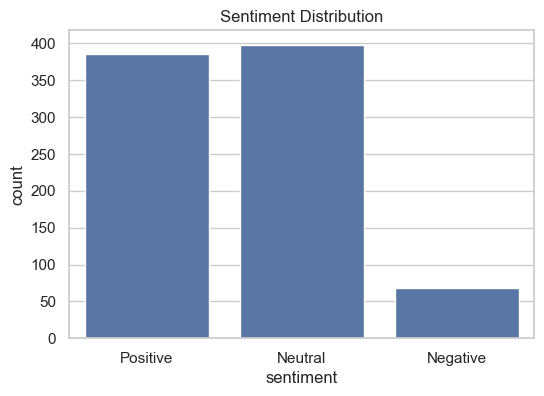

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sentiment")
plt.title("Sentiment Distribution")
plt.savefig("../visualizations/sentiment_distribution.png")
plt.show()


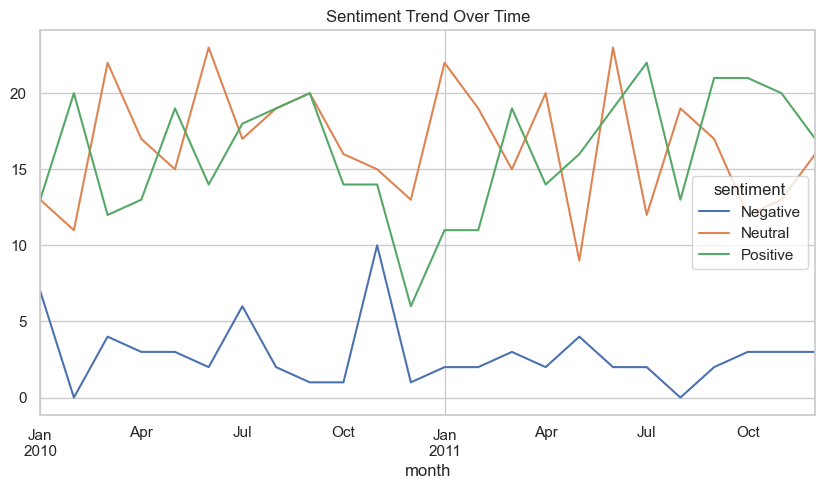

In [10]:
sentiment_trend = df.groupby(["month", "sentiment"]).size().unstack().fillna(0)

sentiment_trend.plot(figsize=(10,5))
plt.title("Sentiment Trend Over Time")
plt.savefig("../visualizations/sentiment_trend_over_time.png")
plt.show()


In [11]:
score_map = {"Positive": 1, "Neutral": 0, "Negative": -1}
df["sentiment_score"] = df["sentiment"].map(score_map)

monthly_scores = (
    df.groupby(["employee_id", "month"])["sentiment_score"]
    .sum()
    .reset_index()
)

monthly_scores.head()


,employee_id,month,sentiment_score
0,bobette.riner@ipgdirect.com,2010-02,4
1,bobette.riner@ipgdirect.com,2010-03,2
2,bobette.riner@ipgdirect.com,2010-04,2
3,bobette.riner@ipgdirect.com,2010-05,0
4,bobette.riner@ipgdirect.com,2010-06,0


In [12]:
latest_month = monthly_scores["month"].max()

top_positive = monthly_scores[monthly_scores["month"] == latest_month] \
    .sort_values(["sentiment_score", "employee_id"], ascending=[False, True]).head(3)

top_negative = monthly_scores[monthly_scores["month"] == latest_month] \
    .sort_values(["sentiment_score", "employee_id"], ascending=[True, True]).head(3)

top_positive, top_negative


(                 employee_id    month  sentiment_score
 143  lydia.delgado@enron.com  2011-12                3
 41    don.baughman@enron.com  2011-12                2
 120  kayne.coulter@enron.com  2011-12                2,
                  employee_id    month  sentiment_score
 61       eric.bass@enron.com  2011-12                1
 83     john.arnold@enron.com  2011-12                1
 102  johnny.palmer@enron.com  2011-12                1)

In [13]:
df["is_negative"] = df["sentiment"] == "Negative"

flight_risk = []

for emp_id, emp_df in df.groupby("employee_id"):
    emp_df = emp_df.sort_values("timestamp")
    for i in range(len(emp_df)):
        window = emp_df.iloc[i:]
        window = window[window["timestamp"] <= emp_df.iloc[i]["timestamp"] + pd.Timedelta(days=30)]
        if window["is_negative"].sum() >= 4:
            flight_risk.append(emp_id)
            break

flight_risk_employees = list(set(flight_risk))
flight_risk_employees


[]

In [14]:
features = (
    df.groupby(["employee_id", "month"])
      .agg(
          message_count=("message", "count"),
          avg_message_length=("message", lambda x: x.str.len().mean()),
          sentiment_score=("sentiment_score", "sum")
      )
      .reset_index()
)

X = features[["message_count", "avg_message_length"]]
y = features["sentiment_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

mean_squared_error(y_test, preds), r2_score(y_test, preds)


(1.480512862932462, 0.35800462393008403)

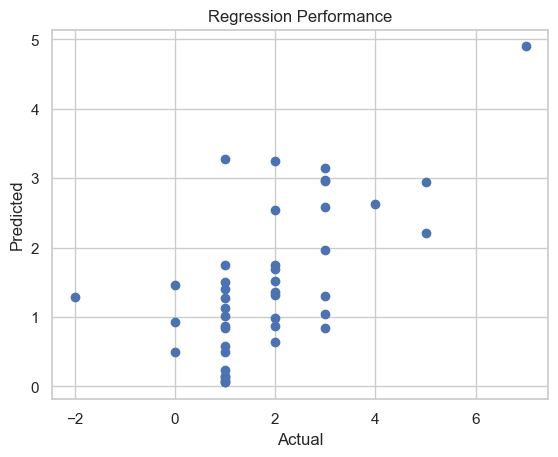

In [15]:
plt.scatter(y_test, preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Regression Performance")
plt.savefig("../visualizations/regression_performance.png")
plt.show()
